In [42]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import joblib
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os

project_root = '/Users/namansoni/Project/macro-regime-classifier'

df = pd.read_csv(os.path.join(project_root, 'data', 'macro_features_clean.csv'), index_col = 0, parse_dates = True)

print(df.head())
print(df.shape)

                 cpi  unemployment  gdp_growth  yield_curve  credit_spread  \
2001-01-31  0.037212           0.3        -1.3         0.57           2.62   
2001-02-28  0.035294           0.0        -1.3         0.51           2.88   
2001-03-31  0.029825           0.1        -1.3         0.75           3.04   
2001-04-30  0.032183           0.1         2.5         1.05           2.73   
2001-05-31  0.035631          -0.1         2.5         1.21           2.65   

            consumer_sent  indust_prod  
2001-01-31           -3.7      -0.4395  
2001-02-28           -4.1      -0.5986  
2001-03-31            0.9      -0.1872  
2001-04-30           -3.1      -0.3271  
2001-05-31            3.6      -0.4336  
(307, 7)


In [43]:
scaler = StandardScaler()

arrays = scaler.fit_transform(df)

In [44]:
scaled_df = pd.DataFrame(arrays, index = df.index, columns = df.columns)
print(scaled_df)

                 cpi  unemployment  gdp_growth  yield_curve  credit_spread  \
2001-01-31  0.662064      0.461170   -0.710597    -0.555839       0.218070   
2001-02-28  0.551779     -0.001507   -0.710597    -0.619306       0.562818   
2001-03-31  0.237267      0.152719   -0.710597    -0.365437       0.774971   
2001-04-30  0.372857      0.152719    0.051826    -0.048100       0.363925   
2001-05-31  0.571141     -0.155733    0.051826     0.121146       0.257849   
...              ...           ...         ...          ...            ...   
2026-03-31  0.411787     -0.155733   -0.028429    -0.619306      -0.882473   
2026-04-30  0.695439     -0.001507   -0.028429    -0.608728      -1.001809   
2026-05-31  0.918185     -0.001507   -0.028429    -0.661617      -1.174183   
2026-06-30  0.513896     -0.155733   -0.028429    -0.841441      -1.227221   
2026-07-31  0.513896     -0.155733   -0.028429    -0.767396      -1.121145   

            consumer_sent  indust_prod  
2001-01-31      -0.807

In [45]:
print(scaled_df.mean())
print(scaled_df.std())
#Since each column in std is off by the same amount, its clear that pandas is using the sample calculation for std, while sklearn uses the population calculation causing a small but recurring difference. 

cpi              5.786179e-17
unemployment    -1.446545e-17
gdp_growth       1.157236e-17
yield_curve     -9.257886e-17
credit_spread   -3.008813e-16
consumer_sent    2.314471e-17
indust_prod     -8.679268e-18
dtype: float64
cpi              1.001633
unemployment     1.001633
gdp_growth       1.001633
yield_curve      1.001633
credit_spread    1.001633
consumer_sent    1.001633
indust_prod      1.001633
dtype: float64


In [46]:
src_folder = os.path.join(project_root, 'src')

os.makedirs(src_folder, exist_ok = True)

joblib.dump(scaler, os.path.join(project_root, src_folder, 'scaler.pkl'))

['/Users/namansoni/Project/macro-regime-classifier/src/scaler.pkl']

In [47]:
loaded_scaler = joblib.load(os.path.join(src_folder, 'scaler.pkl'))
print(loaded_scaler.mean_)

[ 2.56983418e-02  9.77198697e-04  2.24169381e+00  1.09547231e+00
  2.45553746e+00 -2.07166124e-01  3.38009772e-02]


In [48]:
# Day 2 -> Computing BIC scores for each of the K values from 1-7 for each sector, and determining which K value is optimal. 

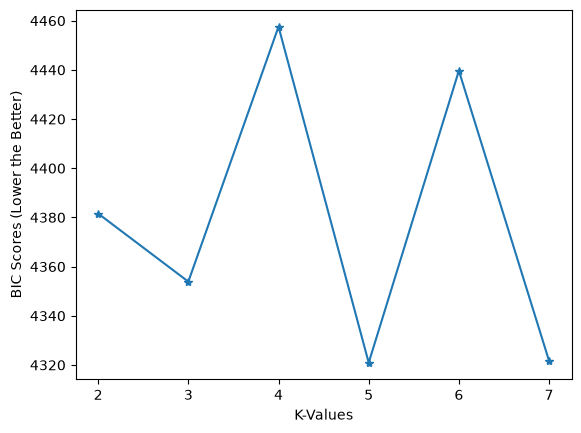

[4381.5731498015875, 4353.883935716055, 4457.559761774961, 4320.924810829713, 4439.646545980286, 4321.668250805133]


In [49]:
bic_scores = []

for i in range(2, 8):
    mixture = GaussianMixture(i, n_init = 10, random_state = 42)
    mixture.fit(scaled_df)
    bic_scores.append(mixture.bic(scaled_df))
    
k_values = list(range(2,8))
plt.plot(k_values, bic_scores, marker = '*')
plt.xlabel('K-Values')
plt.ylabel('BIC Scores (Lower the Better)')
plt.savefig(os.path.join(project_root, 'outputs', 'bic_curve.png'), dpi = 150, bbox_inches = 'tight')
plt.show()
print(bic_scores)

I fit the scaled data with the gaussian mixture model over the range of k values from 2-7, and stored their BIC into a list. The minimum BIC value was at k = 2, followed by k = 3 and k = 7. The k value that is rejected is k = 4 since it has the maximum BIC value (lower the BIC score, the better). The difference between the top options were: k = 2 -> 4618, k = 3 -> 4649, and k = 7 -> 4668. k=7 was also rejected despite being a lower value since it is beat by k = 2 and k =3 by over 20 points. k=4 had a BIC of 4776 which is over 100 points above k=2 and k = 3. I chose k = 3 as my final option since, despite k=2 having the lowest BIC, for the backtesting model, only 2 clusters would give it very little to work with, while k=3 would give it a middle cluster that'll allow it to identify a transition period of the economy rather than only risk-on/risk-off, while maintaining a lower BIC. I will also be checking by running the model over k=2 to ensure the two don't return highly varied results. 

In [50]:
# Day 3 -> Creating two models on the scaled data. 

gmm_k3 = GaussianMixture(3, n_init = 10, random_state = 42)
gmm_k3.fit(scaled_df)
gmm_k2 = GaussianMixture(2, n_init = 10, random_state = 42)
gmm_k2.fit(scaled_df)

k3_pred = gmm_k3.predict(scaled_df)
k3_probs = gmm_k3.predict_proba(scaled_df)

print(k3_pred.shape)
print(k3_probs.shape)
print(np.unique(k3_pred, return_counts= True))

(307,)
(307, 3)
(array([0, 1, 2]), array([ 87,  20, 200]))


In [51]:
joblib.dump(gmm_k2, os.path.join(project_root, src_folder, 'gmm_k2.pkl'))
joblib.dump(gmm_k3, os.path.join(project_root, src_folder, 'gmm_k3.pkl'))

['/Users/namansoni/Project/macro-regime-classifier/src/gmm_k3.pkl']

In [52]:
print(k3_pred[:15])

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [53]:
# Day 4 ->

scaled_df.index[k3_pred == 2]

DatetimeIndex(['2001-01-31', '2001-02-28', '2001-03-31', '2001-04-30',
               '2001-05-31', '2001-06-30', '2001-07-31', '2001-08-31',
               '2001-09-30', '2001-10-31',
               ...
               '2021-01-31', '2021-04-30', '2021-06-30', '2023-05-31',
               '2025-04-30', '2025-05-31', '2025-07-31', '2025-08-31',
               '2025-09-30', '2026-02-28'],
              dtype='datetime64[us]', length=200, freq=None)

In [54]:
k3_pred[scaled_df.index.year == 2008]

array([2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1])

In [55]:
df.loc['2019']

,cpi,unemployment,gdp_growth,yield_curve,credit_spread,consumer_sent,indust_prod
2019-01-31,0.014876,0.1,2.5,0.18,2.38,-7.1,-0.6915
2019-02-28,0.015189,-0.2,2.5,0.21,2.22,2.6,-0.5650
2019-03-31,0.018832,0.0,2.5,0.14,2.26,4.6,0.0386
2019-04-30,0.020006,-0.1,3.4,0.24,2.14,-1.2,-0.6017
2019-05-31,0.017959,-0.1,3.4,0.19,2.37,2.8,0.1180
2019-06-30,0.016712,0.0,3.4,0.25,2.31,-1.8,0.0455
2019-07-31,0.018263,0.1,4.8,0.13,2.13,0.2,-0.4967
2019-08-31,0.017376,-0.1,4.8,0.00,2.26,-8.6,0.6982
2019-09-30,0.016845,-0.1,4.8,0.05,2.20,3.4,-0.3473
2019-10-31,0.017340,0.1,2.8,0.17,2.18,2.3,-0.8636


In [56]:
print(df.loc['2017-01-31'])

cpi              0.025104
unemployment     0.000000
gdp_growth       2.000000
yield_curve      1.260000
credit_spread    2.230000
consumer_sent    0.300000
indust_prod     -0.260300
Name: 2017-01-31 00:00:00, dtype: float64
